In [2]:
# --- sampling regularity check for H45_T ---
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path.cwd() / "data"
EXPECTED_FS = 30.0          # nominal sampling rate (Hz) observed earlier
GAP_MULTIPLIER = 2.0        # a gap is "large" if dt > median * this

# _T files are semicolon-delimited, unlike _F which uses commas
df_T = pd.read_csv(DATA_DIR / "H45_T.csv", sep=";")

ts = df_T["accelerometerTimestamp_sinceReboot(s)"]
dt = ts.diff().dropna()     # diff() drops one row: first sample has no predecessor

expected_dt = 1.0 / EXPECTED_FS

print(f"shape: {df_T.shape}")
print(f"\n--- delta-t statistics (seconds) ---")
print(f"  n samples : {len(dt)}")
print(f"  min       : {dt.min():.6f}")
print(f"  median    : {dt.median():.6f}")
print(f"  mean      : {dt.mean():.6f}")
print(f"  max       : {dt.max():.6f}")
print(f"  std       : {dt.std():.6f}")
print(f"  expected  : {expected_dt:.6f}  (if uniform {EXPECTED_FS:.0f} Hz)")

threshold = dt.median() * GAP_MULTIPLIER
big_gaps = dt[dt > threshold]

print(f"\n--- large gaps (dt > {threshold:.4f} s) ---")
print(f"  count     : {len(big_gaps)}")
print(f"  proportion: {100 * len(big_gaps) / len(dt):.2f}%")

if len(big_gaps) > 0:
    largest = np.sort(big_gaps.values)[::-1][:5]
    print(f"  top 5 (s) : {np.round(largest, 4)}")

shape: (106489, 58)

--- delta-t statistics (seconds) ---
  n samples : 106488
  min       : 0.033657
  median    : 0.033660
  mean      : 0.033666
  max       : 0.033688
  std       : 0.000011
  expected  : 0.033333  (if uniform 30 Hz)

--- large gaps (dt > 0.0673 s) ---
  count     : 0
  proportion: 0.00%


In [3]:
# --- sampling regularity check across all _T files ---
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path.cwd() / "data"
TS_COL = "accelerometerTimestamp_sinceReboot(s)"
GAP_MULTIPLIER = 2.0

t_files = sorted(DATA_DIR.glob("*_T.csv"))
print(f"found {len(t_files)} _T files\n")

records = []
for path in t_files:
    try:
        # usecols limits the read to one column: much faster, far less memory
        ts = pd.read_csv(path, sep=";", usecols=[TS_COL])[TS_COL]
        dt = ts.diff().dropna()

        duration_s = ts.iloc[-1] - ts.iloc[0]
        median_dt = dt.median()
        n_gaps = (dt > median_dt * GAP_MULTIPLIER).sum()

        records.append({
            "subject": path.stem.replace("_T", ""),
            "n_samples": len(ts),
            "duration_min": duration_s / 60.0,
            "fs_hz": (len(ts) - 1) / duration_s,
            "dt_median": median_dt,
            "dt_std": dt.std(),
            "dt_max": dt.max(),
            "n_gaps": n_gaps,
        })
    except Exception as e:
        # never let one bad file kill the whole batch
        print(f"FAILED {path.name}: {type(e).__name__}: {e}")

summary_T = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

print(summary_T.to_string(index=False))

print("\n--- overall ---")
print(f"  files processed  : {len(summary_T)}")
print(f"  duration (min)   : min={summary_T['duration_min'].min():.1f}  "
      f"median={summary_T['duration_min'].median():.1f}  "
      f"max={summary_T['duration_min'].max():.1f}")
print(f"  sampling rate Hz : min={summary_T['fs_hz'].min():.2f}  "
      f"max={summary_T['fs_hz'].max():.2f}")
print(f"  files with gaps  : {(summary_T['n_gaps'] > 0).sum()} / {len(summary_T)}")
print(f"  total gaps found : {summary_T['n_gaps'].sum()}")

found 33 _T files

FAILED L51_T.csv: ValueError: Usecols do not match columns, columns expected but not found: ['accelerometerTimestamp_sinceReboot(s)']
FAILED T20_T.csv: ValueError: Usecols do not match columns, columns expected but not found: ['accelerometerTimestamp_sinceReboot(s)']
FAILED X31_T.csv: ValueError: Usecols do not match columns, columns expected but not found: ['accelerometerTimestamp_sinceReboot(s)']
FAILED Z7_T.csv: ValueError: Usecols do not match columns, columns expected but not found: ['accelerometerTimestamp_sinceReboot(s)']
subject  n_samples  duration_min   fs_hz  dt_median  dt_std  dt_max  n_gaps
    C10     106507       59.7499 29.7088     0.0337  0.0000  0.0337       0
    C28     103586       58.1136 29.7076     0.0337  0.0000  0.0337       0
    C43     106508       59.7502 29.7090     0.0337  0.0000  0.0337       0
    F55      73643       41.3204 29.7037     0.0337  0.0000  0.0337       0
     H2     106497       59.7498 29.7061     0.0337  0.0000  0.033

In [4]:
# --- inspect the 4 _T files that failed to load ---
from pathlib import Path

import pandas as pd

DATA_DIR = Path.cwd() / "data"
FAILED = ["L51_T.csv", "T20_T.csv", "X31_T.csv", "Z7_T.csv"]
REFERENCE = "H45_T.csv"   # a file we know loads correctly

# sep=None + engine="python" lets pandas sniff the delimiter itself
# nrows=0 reads the header only: we just want column names
ref_cols = pd.read_csv(DATA_DIR / REFERENCE, sep=None, engine="python", nrows=0).columns
print(f"{REFERENCE} has {len(ref_cols)} columns")
print(f"  timestamp-like columns: {[c for c in ref_cols if 'imestamp' in c]}\n")

for name in FAILED:
    cols = pd.read_csv(DATA_DIR / name, sep=None, engine="python", nrows=0).columns
    print(f"{name}: {len(cols)} columns")
    print(f"  timestamp-like columns: {[c for c in cols if 'imestamp' in c]}")

    # set operations reveal exactly what differs between the two headers
    missing = set(ref_cols) - set(cols)
    extra = set(cols) - set(ref_cols)
    print(f"  missing vs reference ({len(missing)}): {sorted(missing)[:5]}")
    print(f"  extra   vs reference ({len(extra)}): {sorted(extra)[:5]}")
    print()

H45_T.csv has 58 columns
  timestamp-like columns: ['locationTimestamp_since1970(s)', 'accelerometerTimestamp_sinceReboot(s)', 'motionTimestamp_sinceReboot(s)', 'activityTimestamp_sinceReboot(s)', 'altimeterTimestamp_sinceReboot(s)']

L51_T.csv: 58 columns
  timestamp-like columns: []
  missing vs reference (58): ['accelerometerAccelerationX(G)', 'accelerometerAccelerationY(G)', 'accelerometerAccelerationZ(G)', 'accelerometerTimestamp_sinceReboot(s)', 'activity(txt)']
  extra   vs reference (58): ['ac ivi y imes amp_sinceReboo (s)', 'ac ivi y( x )', 'ac ivi yAc ivi yConfidence(Z)', 'ac ivi yAc ivi yS ar Da e( x )', 'accelerome er imes amp_sinceReboo (s)']

T20_T.csv: 58 columns
  timestamp-like columns: []
  missing vs reference (58): ['accelerometerAccelerationX(G)', 'accelerometerAccelerationY(G)', 'accelerometerAccelerationZ(G)', 'accelerometerTimestamp_sinceReboot(s)', 'activity(txt)']
  extra   vs reference (58): ['ac ivi y imes amp_sinceReboo (s)', 'ac ivi y( x )', 'ac ivi yAc iv

In [5]:
# --- can the 4 corrupted files be repaired? ---
from pathlib import Path

import pandas as pd

DATA_DIR = Path.cwd() / "data"
BROKEN = "L51_T.csv"
TS_COL = "accelerometerTimestamp_sinceReboot(s)"

df = pd.read_csv(DATA_DIR / BROKEN, sep=";")
print(f"raw shape: {df.shape}")
print(f"first 3 raw column names: {list(df.columns[:3])}\n")

# hypothesis: every lowercase 't' in the header was replaced by a space
df.columns = [c.replace(" ", "t") for c in df.columns]
print(f"first 3 repaired column names: {list(df.columns[:3])}")
print(f"target column present: {TS_COL in df.columns}\n")

if TS_COL in df.columns:
    ts = df[TS_COL]
    dt = ts.diff().dropna()
    duration_min = (ts.iloc[-1] - ts.iloc[0]) / 60.0

    print("--- data integrity after repair ---")
    print(f"  n samples      : {len(ts)}")
    print(f"  duration (min) : {duration_min:.2f}")
    print(f"  sampling rate  : {(len(ts) - 1) / (ts.iloc[-1] - ts.iloc[0]):.2f} Hz")
    print(f"  dt median      : {dt.median():.6f}")
    print(f"  dt std         : {dt.std():.6f}")
    print(f"  monotonic ts   : {ts.is_monotonic_increasing}")
    print(f"  accel x head   : {df['accelerometerAccelerationX(G)'].head(3).values}")

raw shape: (106499, 1)
first 3 raw column names: ['time,loca ion imes amp_since1970(s),loca ionLa i ude(WGS84),loca ionLongi ude(WGS84),loca ionAl i ude(m),loca ionSpeed(m/s),loca ionSpeedAccuracy(m/s),loca ionCourse(°),loca ionCourseAccuracy(°),loca ionVer icalAccuracy(m),loca ionHorizon alAccuracy(m),loca ionFloor(Z),accelerome er imes amp_sinceReboo (s),x,y,z,mo ion imes amp_sinceReboo (s),mo ionYaw(rad),mo ionRoll(rad),mo ionPi ch(rad),mo ionRo a ionRa eX(rad/s),mo ionRo a ionRa eY(rad/s),mo ionRo a ionRa eZ(rad/s),mo ionUserAccelera ionX(G),mo ionUserAccelera ionY(G),mo ionUserAccelera ionZ(G),mo ionA  i udeReferenceFrame( x ),mo ionQua ernionX(R),mo ionQua ernionY(R),mo ionQua ernionZ(R),mo ionQua ernionW(R),mo ionGravi yX(G),mo ionGravi yY(G),mo ionGravi yZ(G),mo ionMagne icFieldX(µ ),mo ionMagne icFieldY(µ ),mo ionMagne icFieldZ(µ ),mo ionHeading(°),mo ionMagne icFieldCalibra ionAccuracy(Z),ac ivi y imes amp_sinceReboo (s),ac ivi y( x ),ac ivi yAc ivi yConfidence(Z),ac ivi yAc 

In [6]:
# --- (fixed): inspect the 4 corrupted files properly ---
from pathlib import Path

import pandas as pd

DATA_DIR = Path.cwd() / "data"
BROKEN = "L51_T.csv"

# these files are COMMA-delimited, unlike the other 29 _T files (semicolon)
df = pd.read_csv(DATA_DIR / BROKEN, sep=",")
print(f"shape: {df.shape}")
print(f"columns (first 20): {list(df.columns[:20])}\n")

# the accel axes appear to be named plainly as x/y/z here
axis_cols = [c for c in df.columns if c in ("x", "y", "z")]
print(f"axis columns found: {axis_cols}")

if axis_cols:
    print(f"\n--- data values (are the numbers themselves OK?) ---")
    print(df[axis_cols].describe().to_string())
    print(f"\nfirst 3 rows:\n{df[axis_cols].head(3).to_string()}")

# is there any usable timestamp column?
ts_candidates = [c for c in df.columns if "ime" in c and "s)" in c]
print(f"\ntimestamp candidates: {ts_candidates}")

shape: (106499, 58)
columns (first 20): ['time', 'loca ion imes amp_since1970(s)', 'loca ionLa i ude(WGS84)', 'loca ionLongi ude(WGS84)', 'loca ionAl i ude(m)', 'loca ionSpeed(m/s)', 'loca ionSpeedAccuracy(m/s)', 'loca ionCourse(°)', 'loca ionCourseAccuracy(°)', 'loca ionVer icalAccuracy(m)', 'loca ionHorizon alAccuracy(m)', 'loca ionFloor(Z)', 'accelerome er imes amp_sinceReboo (s)', 'x', 'y', 'z', 'mo ion imes amp_sinceReboo (s)', 'mo ionYaw(rad)', 'mo ionRoll(rad)', 'mo ionPi ch(rad)']

axis columns found: ['x', 'y', 'z']

--- data values (are the numbers themselves OK?) ---
                x           y           z
count 106499.0000 106499.0000 106499.0000
mean       0.2048      0.5739     -0.0681
std        0.8796      0.6514      0.5905
min       -6.1408     -4.1216     -9.2679
25%       -0.3726      0.2039     -0.3661
50%        0.1380      0.6343     -0.0520
75%        0.6761      0.9289      0.2917
max        6.2583      7.2347      4.5574

first 3 rows:
       x      y       

In [7]:
# --- can we recover the broken headers by column position? ---
from pathlib import Path

import pandas as pd

DATA_DIR = Path.cwd() / "data"

ref = pd.read_csv(DATA_DIR / "H45_T.csv", sep=";", nrows=0)
bad = pd.read_csv(DATA_DIR / "L51_T.csv", sep=",", nrows=0)

print(f"reference columns: {len(ref.columns)}")
print(f"broken columns   : {len(bad.columns)}\n")

# align the two headers side by side and eyeball whether positions correspond
print(f"{'idx':>3}  {'REFERENCE (H45_T)':<42}  {'BROKEN (L51_T)':<42}")
print("-" * 92)
for i in range(max(len(ref.columns), len(bad.columns))):
    r = ref.columns[i] if i < len(ref.columns) else "---"
    b = bad.columns[i] if i < len(bad.columns) else "---"
    print(f"{i:>3}  {r:<42}  {b:<42}")

reference columns: 58
broken columns   : 58

idx  REFERENCE (H45_T)                           BROKEN (L51_T)                            
--------------------------------------------------------------------------------------------
  0  loggingTime(txt)                            time                                      
  1  locationTimestamp_since1970(s)              loca ion imes amp_since1970(s)            
  2  locationLatitude(WGS84)                     loca ionLa i ude(WGS84)                   
  3  locationLongitude(WGS84)                    loca ionLongi ude(WGS84)                  
  4  locationAltitude(m)                         loca ionAl i ude(m)                       
  5  locationSpeed(m/s)                          loca ionSpeed(m/s)                        
  6  locationSpeedAccuracy(m/s)                  loca ionSpeedAccuracy(m/s)                
  7  locationCourse(°)                           loca ionCourse(°)                         
  8  locationCourseAccuracy(°)    

In [8]:
# --- Cell 11: unified reader that handles both file variants ---
from pathlib import Path

import pandas as pd

DATA_DIR = Path.cwd() / "data"

# canonical column names, taken from a known-good file
REF_COLUMNS = pd.read_csv(DATA_DIR / "H45_T.csv", sep=";", nrows=0).columns.tolist()

# these 4 _T files are comma-delimited with corrupted headers (all 't' -> ' ')
BROKEN_T = {"L51_T.csv", "T20_T.csv", "X31_T.csv", "Z7_T.csv"}


def read_recording(path, usecols=None):
    """Read one recording, normalising the two known file variants.

    Returns a DataFrame with canonical column names.
    """
    path = Path(path)

    if path.name in BROKEN_T:
        # broken variant: comma-separated, headers unusable -> overwrite by position
        df = pd.read_csv(path, sep=",")
        if len(df.columns) != len(REF_COLUMNS):
            raise ValueError(
                f"{path.name}: expected {len(REF_COLUMNS)} columns, got {len(df.columns)}"
            )
        df.columns = REF_COLUMNS
    else:
        sep = ";" if path.stem.endswith("_T") else ","
        df = pd.read_csv(path, sep=sep)

    return df[usecols] if usecols else df


# --- verify: the previously unreadable files now load correctly ---
TS_COL = "accelerometerTimestamp_sinceReboot(s)"
ACC_COLS = [
    "accelerometerAccelerationX(G)",
    "accelerometerAccelerationY(G)",
    "accelerometerAccelerationZ(G)",
]

for name in sorted(BROKEN_T):
    df = read_recording(DATA_DIR / name, usecols=[TS_COL] + ACC_COLS)
    ts = df[TS_COL]
    duration_min = (ts.iloc[-1] - ts.iloc[0]) / 60.0
    fs = (len(ts) - 1) / (ts.iloc[-1] - ts.iloc[0])
    print(
        f"{name:<12} rows={len(df):>7}  "
        f"duration={duration_min:>6.2f} min  fs={fs:.2f} Hz  "
        f"monotonic={ts.is_monotonic_increasing}"
    )


L51_T.csv    rows= 106499  duration= 59.75 min  fs=29.71 Hz  monotonic=True
T20_T.csv    rows= 106503  duration= 59.75 min  fs=29.71 Hz  monotonic=True
X31_T.csv    rows= 106507  duration= 59.75 min  fs=29.71 Hz  monotonic=True
Z7_T.csv     rows=  78144  duration= 43.84 min  fs=29.71 Hz  monotonic=True


In [9]:
# --- scan all _F files ---

DATA_DIR = Path.cwd() / "data"
TS_COL = "accelerometerTimestamp_sinceReboot(s)"
GAP_MULTIPLIER = 2.0

f_files = sorted(DATA_DIR.glob("*_F.csv"))
print(f"found {len(f_files)} _F files\n")

records = []
for path in f_files:
    try:
        df = read_recording(path, usecols=[TS_COL])
        ts = df[TS_COL]
        dt = ts.diff().dropna()

        duration_s = ts.iloc[-1] - ts.iloc[0]
        median_dt = dt.median()

        records.append({
            "subject": path.stem.replace("_F", ""),
            "n_samples": len(ts),
            "duration_s": duration_s,
            "fs_hz": (len(ts) - 1) / duration_s,
            "dt_median": median_dt,
            "dt_std": dt.std(),
            "dt_max": dt.max(),
            "n_gaps": (dt > median_dt * GAP_MULTIPLIER).sum(),
            "monotonic": ts.is_monotonic_increasing,
        })
    except Exception as e:
        print(f"FAILED {path.name}: {type(e).__name__}: {e}")

summary_F = pd.DataFrame(records)
print(summary_F.to_string(index=False))

print("\n--- overall (_F) ---")
print(f"  files processed  : {len(summary_F)} / {len(f_files)}")
print(f"  duration (s)     : min={summary_F['duration_s'].min():.1f}  "
      f"median={summary_F['duration_s'].median():.1f}  "
      f"max={summary_F['duration_s'].max():.1f}")
print(f"  sampling rate Hz : min={summary_F['fs_hz'].min():.2f}  "
      f"max={summary_F['fs_hz'].max():.2f}")
print(f"  files with gaps  : {(summary_F['n_gaps'] > 0).sum()}")
print(f"  non-monotonic ts : {(~summary_F['monotonic']).sum()}")

found 50 _F files

subject  n_samples  duration_s   fs_hz  dt_median  dt_std  dt_max  n_gaps  monotonic
    B26       6751     67.8630 99.4651     0.0101  0.0000  0.0101       0       True
    C10       6840     68.7590 99.4633     0.0101  0.0000  0.0101       0       True
    C28       6705     67.4007 99.4648     0.0101  0.0000  0.0101       0       True
    C41       6510     65.4430 99.4606     0.0101  0.0000  0.0101       0       True
    C42       6610     66.4467 99.4632     0.0101  0.0000  0.0101       0       True
    C43       6660     66.9484 99.4646     0.0101  0.0000  0.0101       0       True
    G40       7933     79.7458 99.4661     0.0101  0.0000  0.0101       0       True
     H1       6646     66.8062 99.4668     0.0101  0.0000  0.0101       0       True
     H2       7344     76.1500 96.4280     0.0101  0.0261  2.2421       2       True
    H44       6565     65.9938 99.4639     0.0101  0.0000  0.0101       0       True
    H45       6747     67.8244 99.4627     0.0

In [10]:
# --- rescan all _T files using the unified reader ---
GAP_MULTIPLIER = 2.0

t_files = sorted(DATA_DIR.glob("*_T.csv"))

records = []
for path in t_files:
    try:
        ts = read_recording(path, usecols=[TS_COL])[TS_COL]
        dt = ts.diff().dropna()

        duration_s = ts.iloc[-1] - ts.iloc[0]
        median_dt = dt.median()

        records.append({
            "subject": path.stem.replace("_T", ""),
            "n_samples": len(ts),
            "duration_s": duration_s,
            "fs_hz": (len(ts) - 1) / duration_s,
            "dt_max": dt.max(),
            "n_gaps": (dt > median_dt * GAP_MULTIPLIER).sum(),
            "monotonic": ts.is_monotonic_increasing,
        })
    except Exception as e:
        print(f"FAILED {path.name}: {type(e).__name__}: {e}")

summary_T = pd.DataFrame(records)

print(f"_T files processed: {len(summary_T)} / {len(t_files)}")
print(f"  duration (min): min={summary_T['duration_s'].min()/60:.1f}  "
      f"median={summary_T['duration_s'].median()/60:.1f}  "
      f"max={summary_T['duration_s'].max()/60:.1f}")
print(f"  files with gaps: {(summary_T['n_gaps'] > 0).sum()}")

_T files processed: 33 / 33
  duration (min): min=41.3  median=59.8  max=59.8
  files with gaps: 0


In [11]:
# --- full per-subject duration listing for _T ---

t_dur = summary_T[["subject", "duration_s", "n_samples", "fs_hz"]].copy()
t_dur["duration_min"] = t_dur["duration_s"] / 60.0
t_dur = t_dur.sort_values("duration_min")   # shortest first

print(t_dur[["subject", "duration_min", "n_samples", "fs_hz"]].to_string(index=False))

print(f"\n--- distribution ---")
print(f"  n files        : {len(t_dur)}")
print(f"  under 50 min   : {(t_dur['duration_min'] < 50).sum()}")
print(f"  50 to 59 min   : {((t_dur['duration_min'] >= 50) & (t_dur['duration_min'] < 59)).sum()}")
print(f"  59 min or more : {(t_dur['duration_min'] >= 59).sum()}")

subject  duration_min  n_samples   fs_hz
    F55       41.3204      73643 29.7037
    H46       42.7598      76222 29.7089
     Z7       43.8394      78144 29.7081
    C28       58.1136     103586 29.7076
    Y54       58.1136     103586 29.7076
    W53       58.4008     104112 29.7116
    Y57       59.7496     106491 29.7045
     L3       59.7496     106494 29.7054
     Z8       59.7496     106500 29.7070
     H2       59.7498     106497 29.7061
    C10       59.7499     106507 29.7088
    Z39       59.7499     106499 29.7066
    Y55       59.7499     106507 29.7088
     Z5       59.7500     106496 29.7057
    Z14       59.7500     106496 29.7057
    Y56       59.7500     106500 29.7068
    H44       59.7500     106503 29.7077
    T20       59.7500     106503 29.7077
    X31       59.7500     106507 29.7088
    H47       59.7501     106494 29.7051
    H50       59.7501     106508 29.7090
    W22       59.7501     106511 29.7098
    C43       59.7502     106508 29.7090
    L51       59

In [12]:
# are C28_T and Y54_T actually the same data? ---

a = read_recording(DATA_DIR / "C28_T.csv", usecols=[TS_COL] + ACC_COLS)
b = read_recording(DATA_DIR / "Y54_T.csv", usecols=[TS_COL] + ACC_COLS)

print(f"C28 shape: {a.shape}")
print(f"Y54 shape: {b.shape}")
print(f"identical shape: {a.shape == b.shape}\n")

if a.shape == b.shape:
    # .equals() compares values elementwise, treating NaN == NaN as True
    print(f"timestamps identical : {a[TS_COL].equals(b[TS_COL])}")
    print(f"accel data identical : {a[ACC_COLS].equals(b[ACC_COLS])}")
    print(f"entire frame identical: {a.equals(b)}")

    print(f"\nC28 first 3 rows:\n{a.head(3).to_string()}")
    print(f"\nY54 first 3 rows:\n{b.head(3).to_string()}")

C28 shape: (103586, 4)
Y54 shape: (103586, 4)
identical shape: True

timestamps identical : True
accel data identical : True
entire frame identical: True

C28 first 3 rows:
   accelerometerTimestamp_sinceReboot(s)  accelerometerAccelerationX(G)  accelerometerAccelerationY(G)  accelerometerAccelerationZ(G)
0                               587.5733                         0.0206                         0.1170                        -1.0095
1                               587.6070                         0.0198                         0.1166                        -0.9826
2                               587.6407                         0.0246                         0.1129                        -0.9734

Y54 first 3 rows:
   accelerometerTimestamp_sinceReboot(s)  accelerometerAccelerationX(G)  accelerometerAccelerationY(G)  accelerometerAccelerationZ(G)
0                               587.5733                         0.0206                         0.1170                        -1.0095
1   

In [13]:
# --- detect duplicate recordings across the whole dataset ---
import hashlib
from collections import defaultdict

def file_md5(path, chunk_size=1 << 20):
    """MD5 of raw file bytes, read in chunks to bound memory."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


csv_files = sorted(p for p in DATA_DIR.glob("*.csv"))

by_hash = defaultdict(list)
for path in csv_files:
    by_hash[file_md5(path)].append(path.name)

duplicates = {h: names for h, names in by_hash.items() if len(names) > 1}

print(f"csv files scanned : {len(csv_files)}")
print(f"unique contents   : {len(by_hash)}")
print(f"duplicate groups  : {len(duplicates)}\n")

for h, names in sorted(duplicates.items(), key=lambda kv: kv[1]):
    print(f"  {h[:12]}...  {names}")

csv files scanned : 84
unique contents   : 82
duplicate groups  : 2

  807769dc37ff...  ['C28_T.csv', 'Y54_T.csv']
  cdecc86f098a...  ['Z14_T.csv', 'Z5_T.csv']


In [14]:
# --- cross-check against the official md5sums.txt ---

md5_path = DATA_DIR / "md5sums.txt"
print(f"first 5 lines of md5sums.txt:")
with open(md5_path) as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(f"  {line.rstrip()}")

# parse "hash  filename" pairs
official = {}
with open(md5_path) as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 2:
            official[parts[-1].lstrip("*./")] = parts[0]

print(f"\nentries parsed: {len(official)}")

pairs = [("C28_T.csv", "Y54_T.csv"), ("Z14_T.csv", "Z5_T.csv")]
for a, b in pairs:
    ha, hb = official.get(a), official.get(b)
    print(f"\n  {a}: {ha}")
    print(f"  {b}: {hb}")
    print(f"  identical in official manifest: {ha == hb if ha and hb else 'not found'}")

first 5 lines of md5sums.txt:
  225375a45b6f4c998f00c9fe0c8e87bb  Y36_T.csv
  0d8f8701f56bdf1b4be985aa99b99aa1  Z7_T.csv
  cdecc86f098a822e29e7d8cf7cf6cea0  Z5_T.csv
  7be32308ef45173001e345a85d91e598  W22_T.csv
  83e5f944a11624be61540e9c4de15245  C10_T.csv

entries parsed: 84

  C28_T.csv: 807769dc37fffc034a68253cd5907c9f
  Y54_T.csv: 807769dc37fffc034a68253cd5907c9f
  identical in official manifest: True

  Z14_T.csv: cdecc86f098a822e29e7d8cf7cf6cea0
  Z5_T.csv: cdecc86f098a822e29e7d8cf7cf6cea0
  identical in official manifest: True


In [15]:
Path("figures").mkdir(exist_ok=True)

_F mean duration : 69.2 s  (n=50)
_T mean duration : 59.6 min  (n=28, after dedup and excluding <50 min)


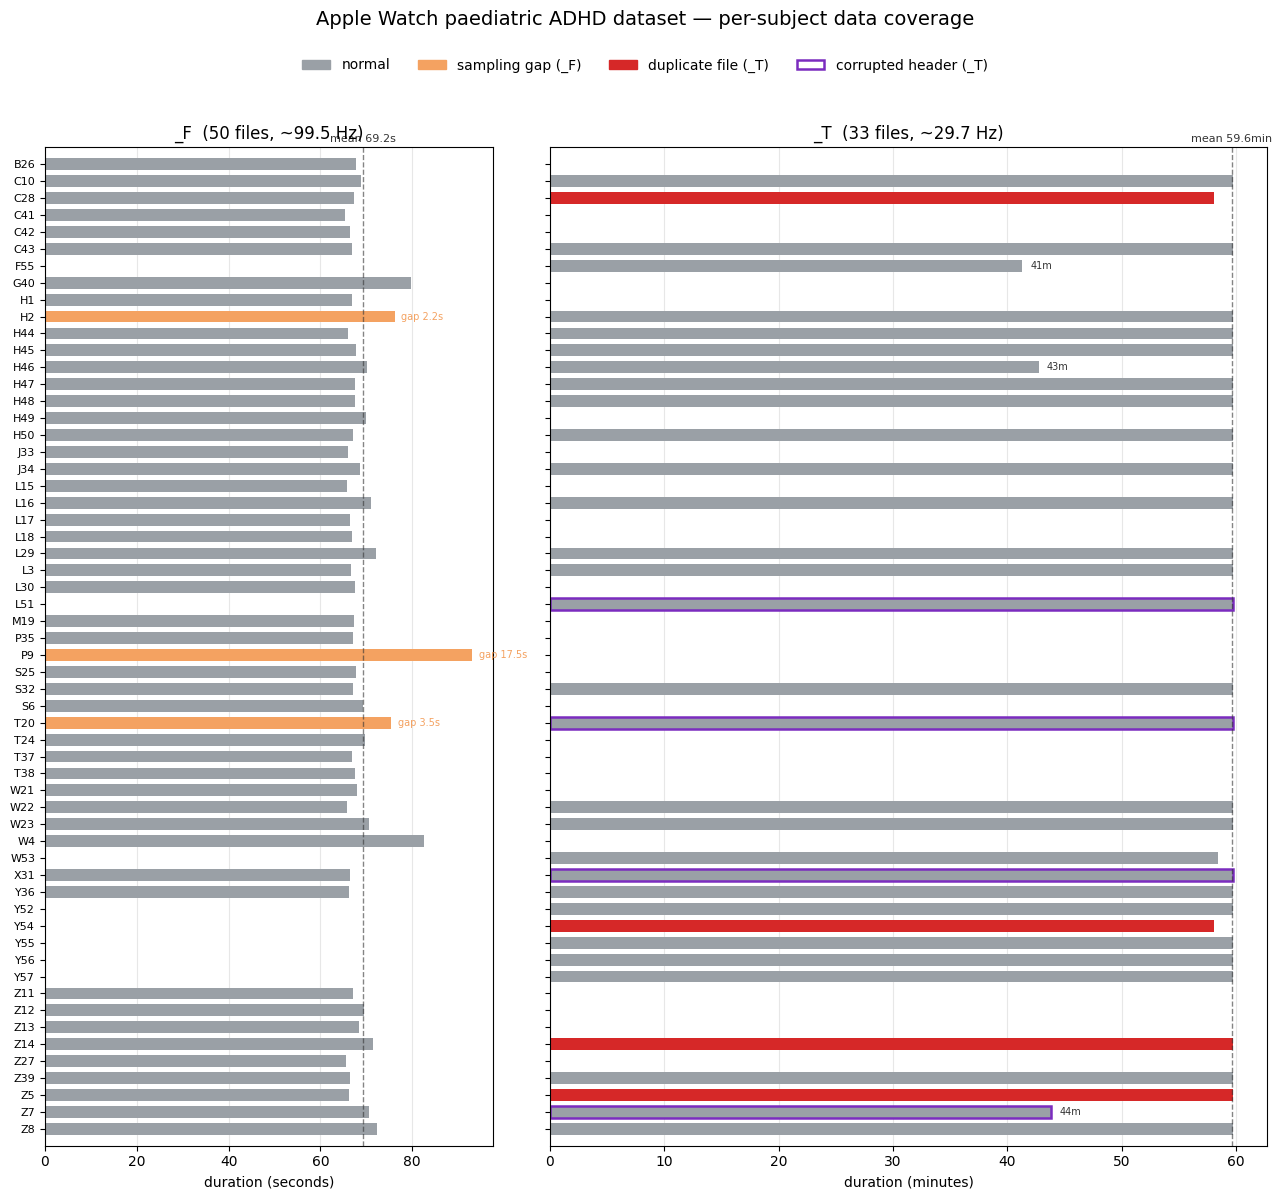

In [16]:
# --- dataset coverage overview ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

Path("figures").mkdir(exist_ok=True)

# --- data quality issues established earlier in this notebook ---
# two pairs of _T files are byte-identical (verified by md5, and confirmed
# duplicated in the dataset's own md5sums.txt -- so this is a flaw in the
# published dataset, not a download error)
DUPLICATE_T_PAIRS = [("C28", "Y54"), ("Z14", "Z5")]
CORRUPT_HEADER_T = {"L51", "T20", "X31", "Z7"}   # comma-delimited, headers mangled

# Used for two purposes: (a) excluding outliers from the reference mean,
# (b) annotating them on the plot. The observed distribution has a clean break --
# three files at 41-44 min, everything else at 58+ -- so 50 sits in the gap.
SHORT_T_THRESHOLD_MIN = 50.0

# what counts as a genuine gap rather than a single dropped sample
GAP_THRESHOLD_S = 0.5

# Keep the alphabetically-first file of each duplicate pair. The two files are
# byte-identical, so this choice does not affect any computed value; it is
# arbitrary and does NOT imply which one is the "original".
DUPLICATE_DROP = {b for _, b in DUPLICATE_T_PAIRS}
DUPLICATE_ALL = {s for pair in DUPLICATE_T_PAIRS for s in pair}

cov = pd.merge(
    summary_F[["subject", "duration_s", "dt_max"]].rename(
        columns={"duration_s": "dur_F", "dt_max": "gap_F"}),
    summary_T[["subject", "duration_s", "dt_max"]].rename(
        columns={"duration_s": "dur_T", "dt_max": "gap_T"}),
    on="subject", how="outer",
).sort_values("subject", ascending=False).reset_index(drop=True)

cov["dur_T_min"] = cov["dur_T"] / 60.0

# --- reference means, computed from the data ---
mean_F = cov["dur_F"].mean()   # all 50 _F files

t_clean = cov[
    cov["dur_T_min"].notna()
    & ~cov["subject"].isin(DUPLICATE_DROP)          # count each duplicate pair once
    & (cov["dur_T_min"] >= SHORT_T_THRESHOLD_MIN)   # exclude the 3 short recordings
]
mean_T = t_clean["dur_T_min"].mean()

print(f"_F mean duration : {mean_F:.1f} s  (n={cov['dur_F'].notna().sum()})")
print(f"_T mean duration : {mean_T:.1f} min  (n={len(t_clean)}, "
      f"after dedup and excluding <{SHORT_T_THRESHOLD_MIN:.0f} min)")

subjects = cov["subject"].tolist()
fig, (ax_f, ax_t) = plt.subplots(
    1, 2, figsize=(13, 12), sharey=True,
    gridspec_kw={"width_ratios": [1, 1.6]},
)

C_OK, C_GAP, C_DUP = "#9aa0a6", "#f4a261", "#d62828"

for i, row in cov.iterrows():
    subj = row["subject"]

    if pd.notna(row["dur_F"]):
        has_gap = row["gap_F"] > GAP_THRESHOLD_S
        ax_f.barh(i, row["dur_F"], color=C_GAP if has_gap else C_OK, height=0.7)
        if has_gap:
            ax_f.text(row["dur_F"] + 1.5, i, f"gap {row['gap_F']:.1f}s",
                      va="center", fontsize=7, color=C_GAP)

    if pd.notna(row["dur_T_min"]):
        ax_t.barh(
            i, row["dur_T_min"], height=0.7,
            color=C_DUP if subj in DUPLICATE_ALL else C_OK,
            edgecolor="#7b2cbf" if subj in CORRUPT_HEADER_T else "none",
            linewidth=1.8 if subj in CORRUPT_HEADER_T else 0,
        )
        if row["dur_T_min"] < SHORT_T_THRESHOLD_MIN:
            ax_t.text(row["dur_T_min"] + 0.7, i, f"{row['dur_T_min']:.0f}m",
                      va="center", fontsize=7, color="#333")

ax_f.axvline(mean_F, color="#333", ls="--", lw=1, alpha=0.6)
ax_f.text(mean_F, len(subjects) + 0.3, f"mean {mean_F:.1f}s",
          fontsize=8, ha="center", color="#333")

ax_t.axvline(mean_T, color="#333", ls="--", lw=1, alpha=0.6)
ax_t.text(mean_T, len(subjects) + 0.3, f"mean {mean_T:.1f}min",
          fontsize=8, ha="center", color="#333")

ax_f.set_title(f"_F  ({cov['dur_F'].notna().sum()} files, ~99.5 Hz)", fontsize=12)
ax_f.set_xlabel("duration (seconds)")
ax_t.set_title(f"_T  ({cov['dur_T'].notna().sum()} files, ~29.7 Hz)", fontsize=12)
ax_t.set_xlabel("duration (minutes)")

ax_f.set_yticks(range(len(subjects)))
ax_f.set_yticklabels(subjects, fontsize=8)
ax_f.set_ylim(-1, len(subjects))

for ax in (ax_f, ax_t):
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)

legend = [
    mpatches.Patch(color=C_OK, label="normal"),
    mpatches.Patch(color=C_GAP, label="sampling gap (_F)"),
    mpatches.Patch(color=C_DUP, label="duplicate file (_T)"),
    mpatches.Patch(facecolor="white", edgecolor="#7b2cbf", linewidth=1.8,
                   label="corrupted header (_T)"),
]
fig.legend(handles=legend, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 0.965), fontsize=10)

fig.suptitle("Apple Watch paediatric ADHD dataset — per-subject data coverage",
             fontsize=14, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("figures/coverage_overview.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
# --- per-subject data quality audit table ---

DEMO_PATH = DATA_DIR / "Demographic and mental health data.csv"
demo = pd.read_csv(DEMO_PATH)

SDQ_COLS = [c for c in demo.columns if c.startswith("SDQ")]
SNAP_COLS = [c for c in demo.columns if c.startswith("a") and c != "ID"]

# --- issue definitions, as established earlier in this notebook ---
# HIGH: data cannot be trusted or cannot be recovered -> subject is excluded
# LOW : data has a defect but remains usable
DUPLICATE_PAIRS = {"C28", "Y54", "Z14", "Z5"}    # byte-identical _T, different children
SDQ_ILLEGAL = {"S32"}                             # SDQ8 = 13, invalid under any coding

CORRUPT_HEADER = {"L51", "T20", "X31", "Z7"}      # mangled header, repaired positionally
F_LARGE_GAP = {"P9": 17.5, "T20": 3.5, "H2": 2.2} # seconds of missing data in _F
T_SHORT = {"F55": 41.3, "H46": 42.8, "Z7": 43.8}  # _T recordings well under one hour

# file presence, from the earlier scans
subjects_F = set(summary_F["subject"])
subjects_T = set(summary_T["subject"])

rows = []
for _, r in demo.iterrows():
    subj = r["ID"]

    has_sdq = r[SDQ_COLS].notna().all()
    has_snap = r[SNAP_COLS].notna().all()

    high, low = [], []

    if subj in DUPLICATE_PAIRS:
        high.append("duplicate _T")
    if not has_sdq:
        high.append("SDQ missing")
    if not has_snap:
        high.append("SNAP missing")
    if subj in SDQ_ILLEGAL:
        high.append("SDQ illegal value")

    if subj in CORRUPT_HEADER:
        low.append("corrupt header")
    if subj in F_LARGE_GAP:
        low.append(f"_F gap {F_LARGE_GAP[subj]}s")
    if subj in T_SHORT:
        low.append(f"_T short {T_SHORT[subj]}min")

    rows.append({
        "subject": subj,
        "_F": "yes" if subj in subjects_F else "-",
        "_T": "yes" if subj in subjects_T else "-",
        "SDQ": "yes" if has_sdq else "-",
        "SNAP": "yes" if has_snap else "-",
        "high_risk": "; ".join(high) if high else "",
        "low_risk": "; ".join(low) if low else "",
        "status": "EXCLUDED" if high else "usable",
    })

audit = pd.DataFrame(rows).sort_values("subject").reset_index(drop=True)

print(audit.to_string(index=False))

print(f"\n--- summary ---")
print(f"  total subjects        : {len(audit)}")
print(f"  excluded (high risk)  : {(audit['status'] == 'EXCLUDED').sum()}")
print(f"  usable                : {(audit['status'] == 'usable').sum()}")
print(f"  usable AND has _T     : "
      f"{((audit['status'] == 'usable') & (audit['_T'] == 'yes')).sum()}")
print(f"  usable, has _T, no low-risk flags: "
      f"{((audit['status'] == 'usable') & (audit['_T'] == 'yes') & (audit['low_risk'] == '')).sum()}")

audit.to_csv("figures/subject_audit.csv", index=False)
print(f"\nsaved to figures/subject_audit.csv")

subject  _F  _T SDQ SNAP                      high_risk                         low_risk   status
    B26 yes   - yes  yes                                                                   usable
    C10 yes yes   -    -      SDQ missing; SNAP missing                                  EXCLUDED
    C28 yes yes yes  yes                   duplicate _T                                  EXCLUDED
    C41 yes   -   -    -      SDQ missing; SNAP missing                                  EXCLUDED
    C42 yes   - yes  yes                                                                   usable
    C43 yes yes yes  yes                                                                   usable
    F55   - yes yes  yes                                                _T short 41.3min   usable
    G40 yes   - yes  yes                                                                   usable
     H1 yes   - yes  yes                                                                   usable
     H2 yes yes yes 